In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the advertising dataset
data = pd.read_csv("/content/advertising.csv")
df = pd.DataFrame(data)
df.head(5)   # Preview first 5 rows

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
# Check data types, missing values, and summary stats
df.info()
print()
print("Missing values:\n", df.isnull().sum())
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64



,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


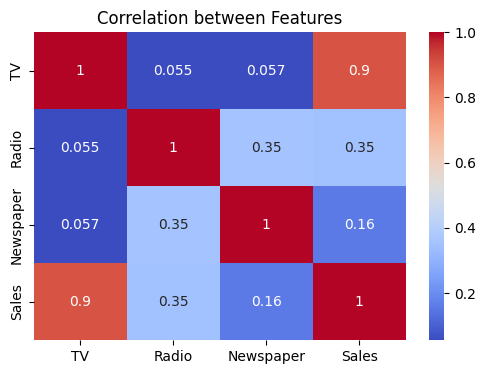

In [4]:
# Visualize correlation between features
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between Features")
plt.show()

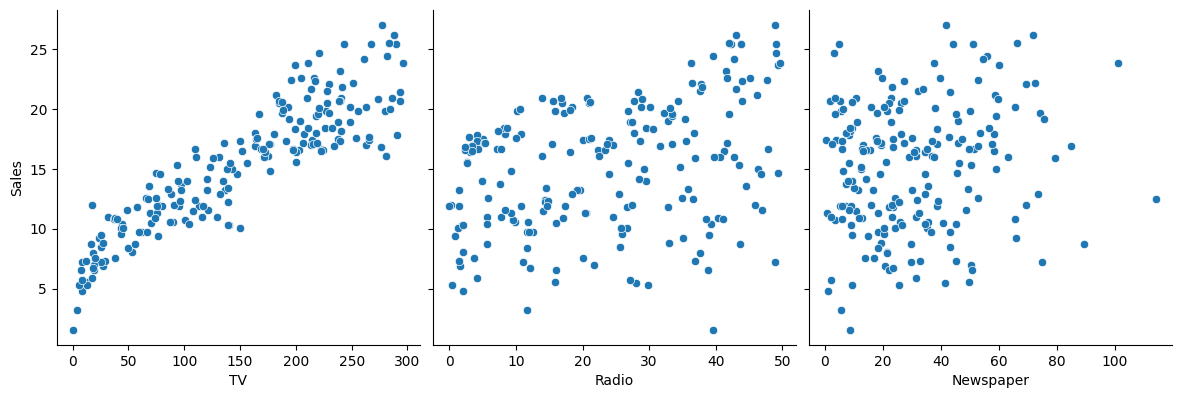

In [5]:
# Scatter plots: each feature vs Sales
sns.pairplot(df, x_vars=['TV','Radio','Newspaper'], y_vars='Sales', height=4, kind='scatter')
plt.show()

In [6]:
# Define predictors and target
X = df[['TV','Radio']]   # Newspaper dropped
y = df['Sales']

In [7]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Standardize features (TV and Radio have different scales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Try 50 alpha values from 0.001 to 1000
alphas = np.logspace(-3, 3, 50)

# RidgeCV auto-selects best alpha using 5-fold CV
model = RidgeCV(alphas=alphas, cv=5)
model.fit(X_train_scaled, y_train)

print("Best alpha selected:", model.alpha_)

Best alpha selected: 0.001


In [10]:
# Generate predictions on train and test sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [11]:
# Compare train vs test metrics to check overfitting
print("---- Train ----")
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2  :", r2_score(y_train, y_train_pred))

print()
print("---- Test ----")
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2  :", r2_score(y_test, y_test_pred))

---- Train ----
MAE : 1.238121474270097
RMSE: 1.637897375578344
R2  : 0.8998966262448543

---- Test ----
MAE : 1.2670390711359802
RMSE: 1.6871931871686083
R2  : 0.9078796272356593


In [12]:
# Check model stability
cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='r2')
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean(), "  Std:", cv_scores.std())

CV R2 scores: [0.87617609 0.93205887 0.92150604 0.84560843 0.9038576 ]
Mean CV R2: 0.8958414081664854   Std: 0.03144746058783118


In [13]:
# Show feature coefficients and intercept
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)
print("Intercept:", model.intercept_)

       Coefficient
TV        4.587019
Radio     1.523959
Intercept: 15.330625000000003


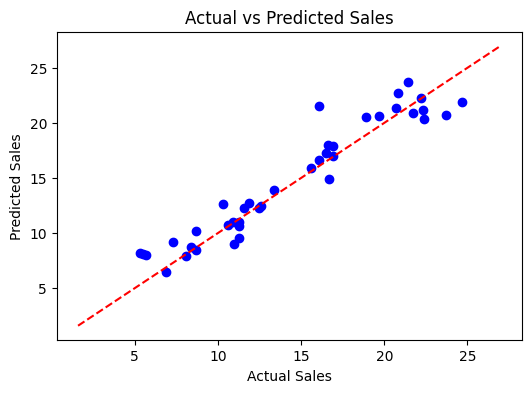

In [14]:
# Points near red line = good predictions
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_test_pred, color='blue')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')   # Ideal line
plt.show()

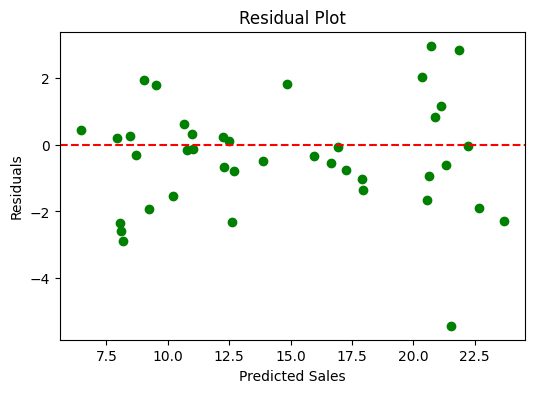

In [15]:
# Residuals = Actual - Predicted. Random scatter = good model
residuals = y_test - y_test_pred

plt.figure(figsize=(6,4))
plt.scatter(y_test_pred, residuals, color='green')
plt.axhline(y=0, color='r', linestyle='--')   # Zero line
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [16]:
# Predict Sales
new_data = pd.DataFrame({'TV':[150], 'Radio':[25]})
new_data_scaled = scaler.transform(new_data)
predicted_sales = model.predict(new_data_scaled)
print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 15.667674612997534


In [17]:
# Save model and scaler

import joblib

joblib.dump(model, 'advertising_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']